In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv("C:\\Users\\himmt\\Customer_Segmentation\\customer_segmentation.csv")

In [7]:
df.head(3)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0


In [9]:
df.shape

(2240, 29)

In [10]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

In [11]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


#### Observation from describe()

1. The oldest birth year in the dataset dates back to 1893, which is quite old, looks like an outlier.
2. Half of the customers last purchase was almost 2 months ago.
3. The ranges are varrying, the data requires scaling. 

In [12]:
df['Year_Birth'].min()

1893

In [17]:
# df.select_dtypes(include=['int64','float64']).info()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

#### Observation from info(): 

1. There is no NULL values, excpet INCOME which has 24 missing data.
2. 90% of the features are numerical. 

In [18]:
df.isna().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [21]:
df.dropna(inplace=True)

In [22]:
df.isna().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Z_CostContact          0
Z_Revenue              0
Response               0
dtype: int64

In [26]:
df['Education'].value_counts()

Education
Graduation    1116
PhD            481
Master         365
2n Cycle       200
Basic           54
Name: count, dtype: int64

In [27]:
df['Marital_Status'].value_counts()

Marital_Status
Married     857
Together    573
Single      471
Divorced    232
Widow        76
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [28]:
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst=True)

In [31]:
df['Dt_Customer'].info()

<class 'pandas.core.series.Series'>
Index: 2216 entries, 0 to 2239
Series name: Dt_Customer
Non-Null Count  Dtype         
--------------  -----         
2216 non-null   datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 34.6 KB


In [32]:
df['Age'] = 2026 - df['Year_Birth']

In [33]:
df['Age'].max()

133

In [34]:
df['Age'].min()

30

In [35]:
### We have two columns 'No. of Kids' and 'No. of Teens' we can combine that and make a single column saying 'No. of Kids' 

df['No_of_kids'] = df['Kidhome'] + df['Teenhome']

In [38]:
df['No_of_kids']

0       0
1       2
2       0
3       1
4       1
       ..
2235    1
2236    3
2237    0
2238    1
2239    2
Name: No_of_kids, Length: 2216, dtype: int64

In [40]:
### There are lot of columns for spendings, which are kind of irrelevant becuase for this project we mostly need the total spending amount rather than 
### what they spend on so, we will combine them all. 

spend_cols = ['MntWines','MntFruits','MntMeatProducts','MntFishProducts','MntSweetProducts','MntGoldProds']

df['total_spendings'] = df[spend_cols].sum(axis=1)


In [41]:
df['total_spendings']

0       1617
1         27
2        776
3         53
4        422
        ... 
2235    1341
2236     444
2237    1241
2238     843
2239     172
Name: total_spendings, Length: 2216, dtype: int64

In [44]:
### Since this project is to understand customer segmentation, one important thing to evalute is how long is a customer has been associated with us ?

df['customer_since'] = (pd.Timestamp('today') - df['Dt_Customer']).dt.days

In [46]:
df['customer_since'].min()

4351

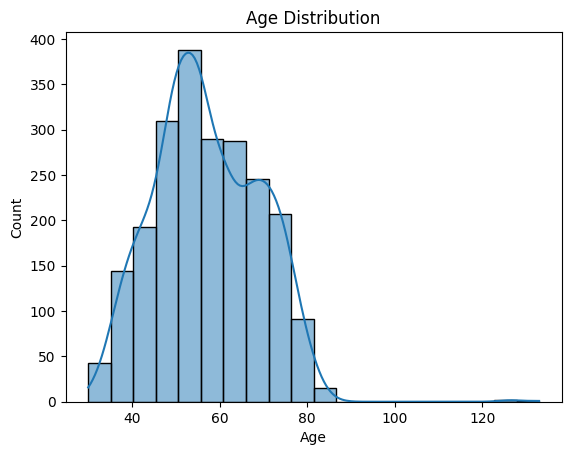

In [47]:
### Its important to understand the age distribution of our customers: 

sns.histplot(df['Age'], bins=20, kde=True)
plt.title('Age Distribution')
plt.show()

#### Observations: 

1. Most of our customers are middle aged falling within the age group between 50 to 70. 
2. We have a few outliers at the moment. 

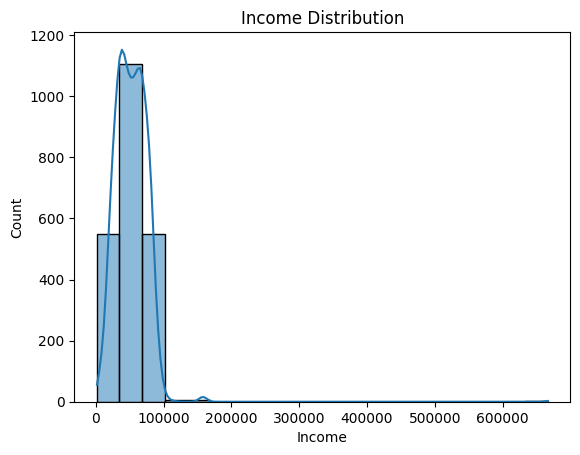

In [49]:
#### Same with Income, to what is our customer's income potential:

sns.histplot(df['Income'], bins=20, kde=True)
plt.title('Income Distribution')
plt.show()

#### Observations: 

1. Most of our customers are earning within 100K.
2. We have a big tail, which suggests that there is big income parity, but the count is very low.

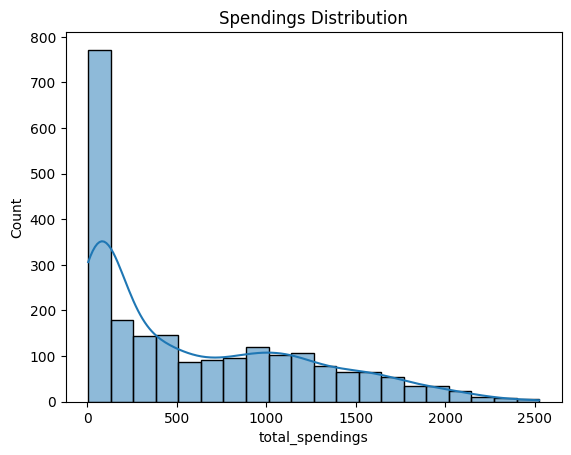

In [51]:
#### Same with Spendings, to what is our customer's spending potential:

sns.histplot(df['total_spendings'], bins=20, kde=True)
plt.title('Spendings Distribution')
plt.show()

#### Observations: 

1. A big chunk of our customers spends very less.
2. The highest that our customers spend is 2500.

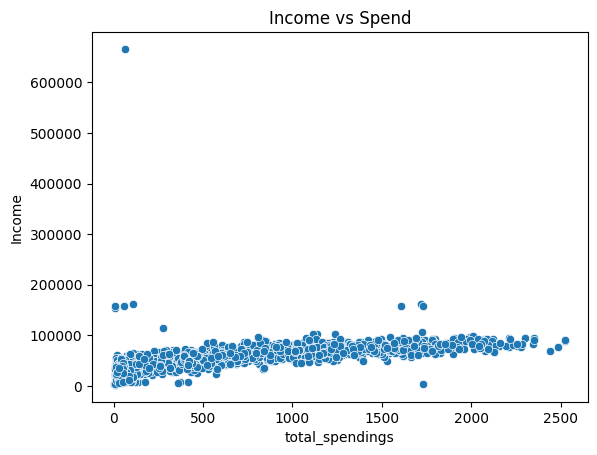

In [52]:
sns.scatterplot(x=df['total_spendings'], y=df['Income'])
plt.title('Income vs Spend')
plt.show()

#### Observations: 

1. We have an intersting observation, same income band customers have varried spending habbits.
2. There are a few outliers, where customers earning the most are still spending in the lower band.
3. I think a better observation can be a age wise spending potential. 

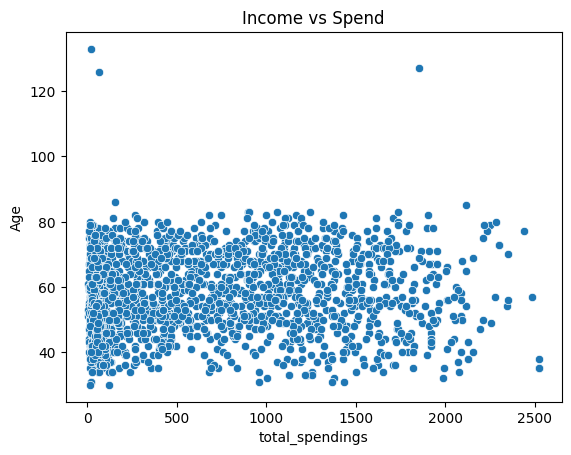

In [53]:
sns.scatterplot(x=df['total_spendings'], y=df['Age'])
plt.title('Income vs Spend')
plt.show()

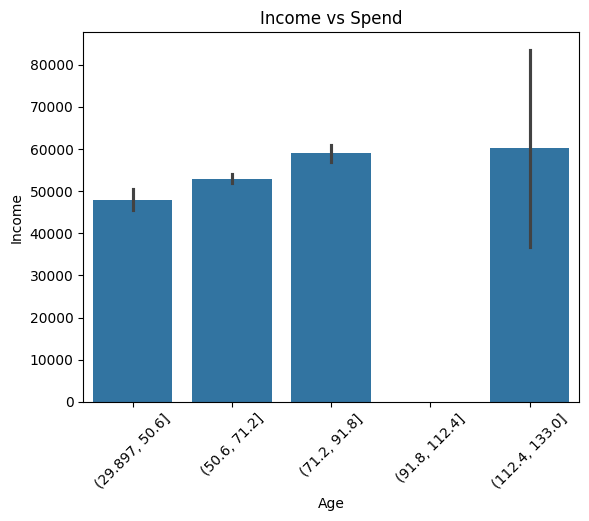

In [60]:
sns.barplot(x=pd.cut(df['Age'], bins=5), y=df['Income'])
plt.title('Income vs Spend')
plt.xticks(rotation=45)
plt.show()

#### Observations: 

1. Gradual increase in income as age increases from 30 to 70, it is expected.
2. Little unsual of people from very older age group have such a high income.

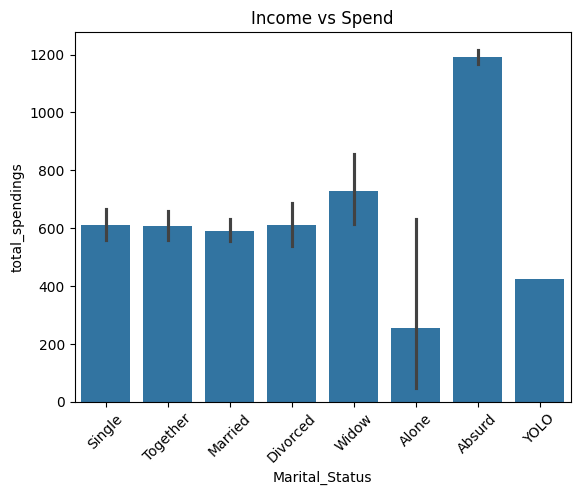

In [61]:
sns.barplot(x= df['Marital_Status'], y=df['total_spendings'])
plt.title('Income vs Spend')
plt.xticks(rotation=45)
plt.show()

C:\Users\himmt\AppData\Local\Temp\ipykernel_13296\3925688663.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(df['Marital_Status'].unique(), rotation=45)


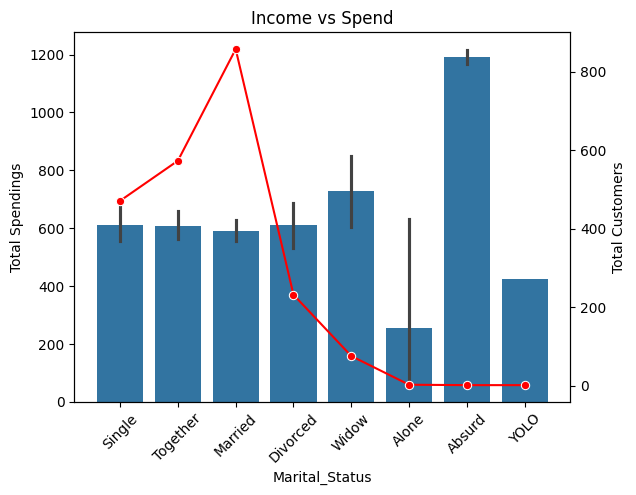

In [63]:
fig, ax1 = plt.subplots()

sns.barplot(x=df['Marital_Status'], y=df['total_spendings'], ax=ax1)

ax2 = ax1.twinx()
customer_counts = df['Marital_Status'].value_counts().reindex(df['Marital_Status'].unique())
sns.lineplot(x=range(len(customer_counts)), y=customer_counts.values, ax=ax2, color='red', marker='o')

ax1.set_xlabel('Marital_Status')
ax1.set_ylabel('Total Spendings')
ax2.set_ylabel('Total Customers')
plt.title('Income vs Spend')
ax1.set_xticklabels(df['Marital_Status'].unique(), rotation=45)
plt.show()

#### Observations: 

1. Our target customer are the one with marital status as: 'Together' and 'Married'.
2. Then followed by the single people.
3. Absurd and widows although spends alot but doesn't constitute a very large customer base. 

In [66]:
corr = df[['Income','Age','Recency','total_spendings','NumStorePurchases','NumWebPurchases']].corr()

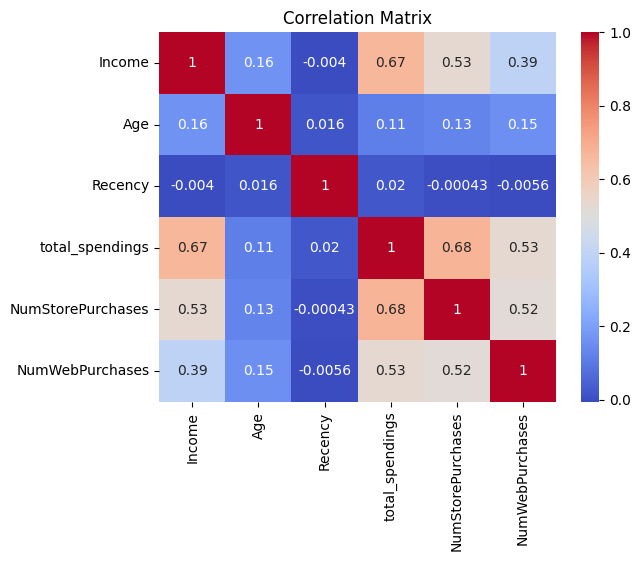

In [68]:
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

#### Observations: 

1. Income has a very strong influence when it comes to total spendings by customers, their Store purchases and their web purchases.
2. Recency is almost unexplainable by any of the factor, reflecting to more investigation for features that can explain recency. Our its a products
   related issue.
3. Age didnot seem to have any impact on the spendings and purchases.

In [69]:
#### We know will do a quick spending vs the education level comparison,  but this time we shall take the avg income: 

Edu_groups = df.groupby('Education')['total_spendings'].mean().sort_values(ascending=False)

In [70]:
Edu_groups

Education
PhD           676.733888
Graduation    621.686380
Master        609.767123
2n Cycle      494.930000
Basic          81.796296
Name: total_spendings, dtype: float64

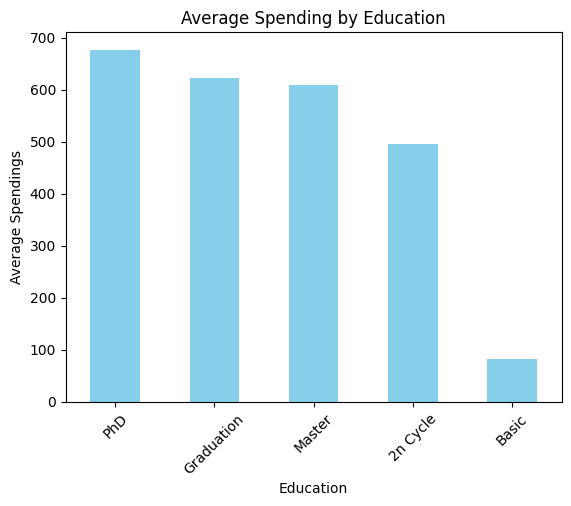

In [73]:
Edu_groups.plot(kind='bar', color='skyblue')
plt.title("Average Spending by Education")
plt.ylabel("Average Spendings")
plt.xticks(rotation=45)
plt.show()

In [81]:
df['Accepted_Any'] = df[['AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1','AcceptedCmp2','Response']].sum(axis=1)

In [82]:
df['Accepted_Any'] = df['Accepted_Any'].apply(lambda x: 1 if x>0 else 0)

In [83]:
df['Accepted_Any'].unique()

array([1, 0], dtype=int64)

In [84]:
#### We would want to check the response of different status of people to our marketing campaigns: 

marital_groups = df.groupby('Marital_Status')['Accepted_Any'].mean().sort_values(ascending=False)

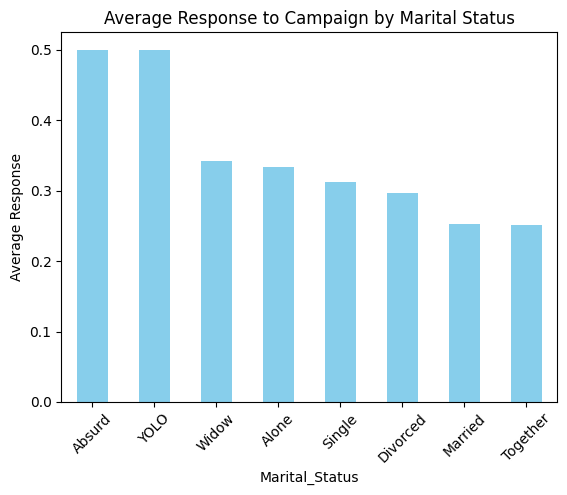

In [85]:
marital_groups.plot(kind='bar', color='skyblue')
plt.title("Average Response to Campaign by Marital Status")
plt.ylabel("Average Response")
plt.xticks(rotation=45)
plt.show()

#### Now we will start with the Clustering algorithm: 

In [86]:
features = ['Age','Income','total_spendings','NumStorePurchases','NumWebPurchases','NumWebVisitsMonth','Response']

In [87]:
X = df[features].copy()

In [89]:
X.head(3)

,Age,Income,total_spendings,NumStorePurchases,NumWebPurchases,NumWebVisitsMonth,Response
0,69,58138.0,1617,4,8,7,1
1,72,46344.0,27,2,1,5,0
2,61,71613.0,776,10,8,4,0


In [90]:
#### We need to now scale the data because the ranges are very different: 

from sklearn.preprocessing import StandardScaler

In [91]:
scaler = StandardScaler()

In [92]:
X_Scaled = scaler.fit_transform(X)

In [94]:
X_Scaled

array([[ 0.98644293,  0.2340627 ,  1.67548812, ...,  1.42855332,
         0.69323197,  2.37795178],
       [ 1.23680074, -0.23455948, -0.96235832, ..., -1.12588116,
        -0.1315745 , -0.42052997],
       [ 0.31882209,  0.76947764,  0.28024985, ...,  1.42855332,
        -0.54397773, -0.42052997],
       ...,
       [-1.01641959,  0.18809052,  1.05169551, ..., -0.76096195,
         0.28082874, -0.42052997],
       [ 1.06989553,  0.67538765,  0.39140438, ...,  0.6987149 ,
        -0.95638097, -0.42052997],
       [ 1.23680074,  0.02470453, -0.7218    , ..., -0.39604274,
         0.69323197,  2.37795178]])

In [95]:
from sklearn.cluster import KMeans

In [97]:
wcss = []

for i in range(2,10): 
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(X_Scaled)
    wcss.append(kmeans.inertia_)

In [98]:
wcss

[10168.238555886724,
 8640.701638372237,
 7844.709161762648,
 6967.088195606555,
 6624.466945730395,
 5805.716869091149,
 5494.566936069241,
 5355.148438872824]

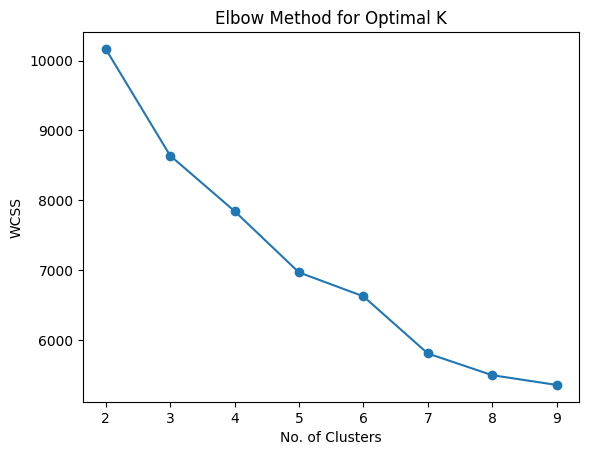

In [99]:
plt.plot(range(2,10), wcss, marker = "o")
plt.title('Elbow Method for Optimal K')
plt.xlabel('No. of Clusters')
plt.ylabel('WCSS')
plt.show()

In [100]:
kmeans = KMeans(n_clusters=6)
df['Clusters'] = kmeans.fit_predict(X_Scaled)

In [101]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,Complain,Z_CostContact,Z_Revenue,Response,Age,No_of_kids,total_spendings,customer_since,Accepted_Any,Clusters
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,0,3,11,1,69,0,1617,5014,1,5
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,0,3,11,0,72,2,27,4464,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,0,3,11,0,61,0,776,4663,0,2
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0,3,11,0,42,1,53,4490,0,1
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,0,3,11,0,45,1,422,4512,0,1


In [102]:
Cluster_summary = df.groupby('Clusters')[features].mean()

In [103]:
### Determining how many customers are in each clusters: 

df['Clusters'].value_counts()

Clusters
1    651
3    435
2    416
0    380
5    191
4    143
Name: count, dtype: int64

In [105]:
from sklearn.decomposition import PCA

In [106]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_Scaled)
df['PCA1'], df['PCA2'] = pca_data[:,0], pca_data[:,1]

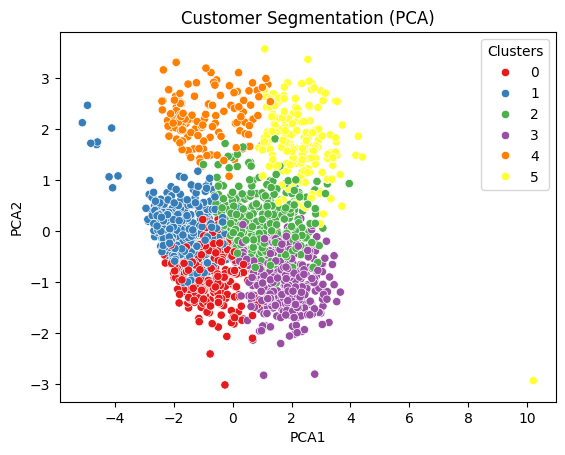

In [108]:
sns.scatterplot(x='PCA1', y='PCA2', hue='Clusters', data=df, palette='Set1' )
plt.title("Customer Segmentation (PCA)")
plt.show()

#### Observations: 

1. Blue (Cluster 1) is the most isolated: sits far left (PC1: -5 to -3) with very few points, clearly a distinct and rare customer segment. These are     likely outliers or VIP customers
2. Orange (4) and Yellow (5) are well separated at the top: both sit in the upper region with minimal overlap, these are two distinct customer           segments worth targeting differently
3. Red (0), Blue(1 center), Purple (3) and Green (2) overlap heavily in the center: these clusters are not clearly distinct: suggests K=6 may be too      high, consider reducing clusters
4. One Yellow point at PC1=10: extreme outlier, far from all other clusters this could be an exceptionally high-value or anomalous customer worth         investigating separately

In [109]:
### Packaging the model in joblib

import joblib

joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [110]:
joblib.dump(kmeans, 'kmeans_model.pkl')

['kmeans_model.pkl']

In [50]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'No_of_kids', 'total_spendings', 'customer_since'],
      dtype='object')